In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys
sys.path.insert(0, "../")

from pathlib import Path
import json

import pandas as pd
import seaborn as sns
import numpy as np

from matplotlib.ticker import LogFormatterMathtext


import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    "font.size": 14,          # default font size
    "axes.titlesize": 16,     # title
    "axes.labelsize": 15,     # x/y labels
    "xtick.labelsize": 13,    # x tick labels
    "ytick.labelsize": 13,    # y tick labels
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
})

## Switch between motif length and series-length experiments

In [2]:
max_memory = "8 GB"
experiment = "motif length"

#experiment = "series-length"

## Load data

In [3]:
# Noise relative to the amplitude of the sine wave
amplitude = 5.0
x_col = "n" if experiment == "series-length" else "motif length"

def load_synthetic_results(result_dir, experiment):
  result_dir = Path(result_dir)
  stem = experiment.replace(" ", "-")

  summary_path = result_dir / f"{stem}_summary.csv"
  jsonl_path = result_dir / f"{stem}_runs.jsonl"

  summary = pd.read_csv(summary_path)

  with jsonl_path.open() as f:
      runs = [json.loads(line) for line in f]

  return summary, runs


def aggregate_synthetic(summary, experiment, amplitude, backend_label):  
  agg = (
      summary
      .groupby([x_col, "noise"], as_index=False)
      .agg(
          time_mean=("time in s", "mean"),
          time_std=("time in s", "std"),
          f_score_mean=("f_score", "mean"),
          precision_mean=("precision", "mean"),
          recall_mean=("recall", "mean"),
          extent_mean=("selected extent", "mean"),
          ground_truth_extent=("ground truth extent", "mean"),
      )
  )

  agg["backend"] = backend_label
  agg["relative_noise"] = agg["noise"] / amplitude
  agg["relative_noise_pct"] = 100 * agg["relative_noise"]
  agg["relative_noise_label"] = agg["relative_noise_pct"].map(
      lambda value: f"{value:g}%"
  )

  threshold = 1e-2
  agg["relative_extent"] = np.where(
      agg["extent_mean"] < threshold,
      1.0,
      np.minimum(agg["extent_mean"] / agg["ground_truth_extent"], 1.0),
  )

  return agg


In [4]:
scampi_summary, scampi_runs = load_synthetic_results(
  "../tests/results/synthetic_scampi",
  experiment,
)


stumpy_summary, stumpy_runs = load_synthetic_results(
  "../tests/results/synthetic_stumpy",
  "series-length",
)

agg = aggregate_synthetic(
  scampi_summary,
  experiment,
  amplitude,
  backend_label="SCAMPI",
)

stumpy_agg = aggregate_synthetic(
  stumpy_summary,
  "series-length",
  amplitude,
  backend_label="STUMPY",
)

agg_all = pd.concat([agg, stumpy_agg], ignore_index=True)
agg_all.head()

,motif length,noise,time_mean,time_std,f_score_mean,precision_mean,recall_mean,extent_mean,ground_truth_extent,backend,relative_noise,relative_noise_pct,relative_noise_label,relative_extent
0,256,0.00,0.262226,0.002302,1.0,1.0,1.0,5.179587e-08,0.000001,SCAMPI,0.00,0.0,0%,1.000000
1,256,0.05,0.301500,0.020443,1.0,1.0,1.0,1.199837e-01,0.119984,SCAMPI,0.01,1.0,1%,1.000000
2,256,0.10,0.359466,0.014752,1.0,1.0,1.0,4.796222e-01,0.479623,SCAMPI,0.02,2.0,2%,0.999999
3,256,0.20,1.105108,0.148075,1.0,1.0,1.0,1.913522e+00,1.913522,SCAMPI,0.04,4.0,4%,1.000000
4,256,0.25,2.844608,0.643728,1.0,1.0,1.0,2.981249e+00,2.984090,SCAMPI,0.05,5.0,5%,0.999048


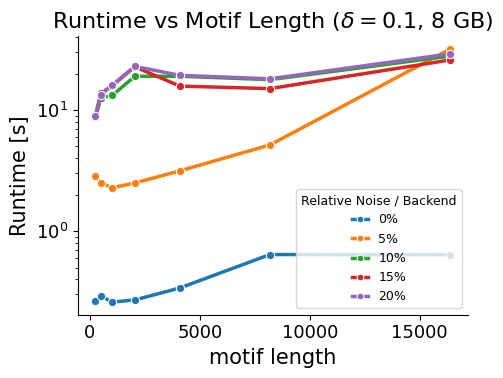

In [5]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]

# All requested noise levels for SCAMPi
scampi_df = agg_all[
    (agg_all["backend"] == "SCAMPI")
    & (agg_all["relative_noise_label"].isin(selected_noise))
].sort_values(x_col)

# The one available STUMPY noise level
stumpy_df = agg_all[
    agg_all["backend"] == "STUMPY"
].sort_values(x_col)

fig, ax = plt.subplots(figsize=(5, 4))

# Plot all SCAMPi noise levels
sns.lineplot(
    data=scampi_df,
    x=x_col,
    y="time_mean",
    hue="relative_noise_label",
    marker="o",
    linewidth=2.5,
    ax=ax,
)

# Add STUMPY as one additional line
if experiment == "series-length":
    sns.lineplot(
        data=stumpy_df,
        x=x_col,
        y="time_mean",
        marker="s",
        linewidth=1.5,
        linestyle="--",
        color="black",
        label="Exact$^*$; $O(n^2)$",
        ax=ax,
    )


#ax.set_xscale("log")
ax.set_yscale("log")

sns.despine()

ax.set_xlabel(x_col)
ax.set_ylabel("Runtime [s]")
ax.set_title(
    rf"Runtime vs {experiment.title()} ($\delta=0.1$, {max_memory})"
)

ax.legend(
    title="Relative Noise / Backend",
    loc="lower right",   # or "upper left", etc.
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    markerscale=0.8,
    handlelength=1.3,
)

plt.tight_layout()

plt.tight_layout()
plt.savefig(
    f"images/synthetic_runtime_lineplot_{experiment.replace(' ', '-')}.pdf",
    bbox_inches="tight",
)
plt.show()

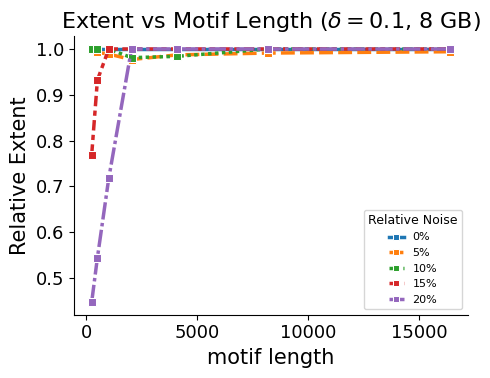

In [6]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[
    agg["relative_noise_label"].isin(selected_noise)
]

fig, ax = plt.subplots(figsize=(5, 4))

sns.lineplot(
    data=plot_df,
    x=x_col,
    y="relative_extent",
    hue="relative_noise_label",
    style="relative_noise_label",
    linewidth=2.5, 
    marker="s",
    ax=ax,
)

sns.despine()

# if experiment == "series-length":
# ax.set_xscale("log")
# ax.xaxis.set_major_formatter(LogFormatterMathtext())
    
ax.set_xlabel(x_col)
ax.set_ylabel("Relative Extent")
ax.set_title(rf"Extent vs {experiment.title() } ($\delta=0.1$, {max_memory})")
ax.legend(
    title="Relative Noise",
    loc="lower right",   # or "upper left", etc.
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    markerscale=0.8,
    handlelength=1.3,
)


plt.tight_layout()
plt.savefig(
    f"images/synthetic_quality2_lineplot_{experiment.replace(' ', '-')}.pdf",
    bbox_inches="tight",
)
plt.show()

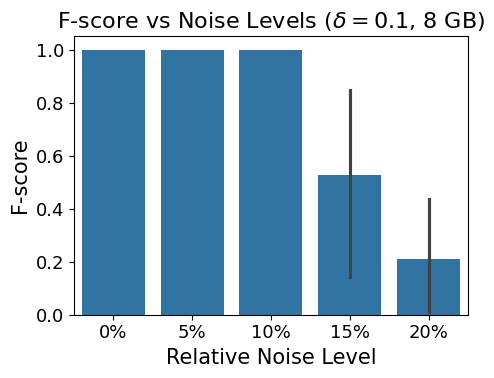

In [7]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(
    data=plot_df,
    x="relative_noise_label",
    y="f_score_mean",
    #hue="relative_noise_label",
    ax=ax,
)

ax.set_xlabel("Relative Noise Level")
ax.set_ylabel("F-score")
ax.set_title(rf"F-score vs Noise Levels ($\delta=0.1$, {max_memory})")

plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig(
#    f"images/synthetic_quality_noise_barplot_{experiment.replace(' ','-')}.pdf",
#    bbox_inches="tight",
#)
plt.show()

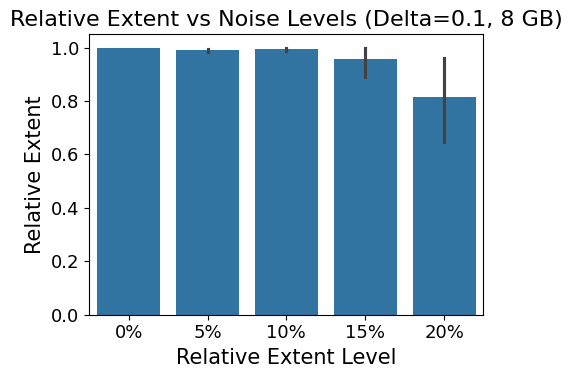

In [8]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(
    data=plot_df,
    x="relative_noise_label",
    y="relative_extent",
    #hue="relative_noise_label",
    ax=ax,
)

ax.set_xlabel("Relative Extent Level")
ax.set_ylabel("Relative Extent")
ax.set_title(f"Relative Extent vs Noise Levels (Delta=0.1, {max_memory})")

plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig(
#    f"images/synthetic_extent_noise_barplot_{experiment.replace(' ','-')}.pdf",
#    bbox_inches="tight",
#)
plt.show()